# Getting Started

This tutorial walks through a complete Jim run on a toy problem.
We inject a non-spinning BBH signal using TaylorF2, fix every
parameter except chirp mass ($\mathcal{M}_c$) and mass ratio ($q$),
and sample just those two to keep things fast and easy to visualise.

## Setup

In [1]:
import logging
import jax

from jimgw.core.single_event.detector import get_H1, get_L1
from jimgw.core.single_event.waveform import RippleTaylorF2
from jimgw.core.single_event.likelihood import TransientLikelihoodFD
from jimgw.core.single_event.transforms import MassRatioToSymmetricMassRatioTransform
from jimgw.core.prior import CombinePrior, UniformPrior
from jimgw.core.jim import Jim
from jimgw.samplers.config import FlowMCConfig

jax.config.update("jax_enable_x64", True)
logging.getLogger("flowMC").setLevel(logging.WARNING)

## 1. Define injection parameters

We use a non-spinning BBH signal with zero tidal deformability. Only
`M_c` and `q` will be sampled; every other parameter is fixed to
the injection value.

In [2]:
gps_time = 1126259462.0

injection_parameters = {
    "M_c": 30.0,
    "eta": 0.24,
    "s1_z": 0.0,
    "s2_z": 0.0,
    "lambda_1": 0.0,
    "lambda_2": 0.0,
    "d_L": 1000.0,
    "t_c": 0.0,
    "phase_c": 0.0,
    "iota": 0.4,
    "psi": 0.3,
    "ra": 1.5,
    "dec": 0.5,
}

## 2. Set up detectors and inject the signal

In [3]:
waveform = RippleTaylorF2(f_ref=20.0)

f_min = 20.0
f_max = 1024.0
duration = 4.0
sampling_frequency = 2 * f_max

ifos = [get_H1(), get_L1()]
for ifo in ifos:
    ifo.load_and_set_psd()
    ifo.inject_signal(
        duration,
        sampling_frequency,
        trigger_time=gps_time,
        waveform_model=waveform,
        parameters=injection_parameters,
        f_min=f_min,
        f_max=f_max,
    )

## 3. Define the prior

We only sample `M_c` and `q`, so we only need priors for those two.
The prior is defined in the **prior space** — the space before any
likelihood transforms are applied.

In [4]:
prior = CombinePrior(
    [
        UniformPrior(29.0, 31.0, ["M_c"]),
        UniformPrior(0.125, 1.0, ["q"]),
    ]
)

## 4. Define transforms

**Likelihood transforms** convert parameters from the prior space to
the space the waveform model expects. TaylorF2 takes $\eta$, but we
placed our prior on $q$, so we need `MassRatioToSymmetricMassRatioTransform`
to map $q$ to $\eta$ before the likelihood is evaluated.

**Sample transforms** convert parameters from the sampling space to
the prior space. Leaving this list empty means the sampler operates
directly in the prior space. You can add transforms here to reparameterise
into a space that is easier to sample (e.g. unbounded coordinates,
decorrelated parameters), without changing the prior definition.

In [5]:
likelihood_transforms = [MassRatioToSymmetricMassRatioTransform]

sample_transforms = []  # sampler operates directly in prior space (M_c, q)

## 5. Build the likelihood

All parameters that are not being sampled (or transformed) must be
baked into the likelihood via `fixed_parameters`.

In [6]:
fixed_parameters = {
    k: v
    for k, v in injection_parameters.items()
    if k not in ["M_c", "eta"]
}

likelihood = TransientLikelihoodFD(
    ifos,
    waveform=waveform,
    trigger_time=gps_time,
    f_min=f_min,
    f_max=f_max,
    fixed_parameters=fixed_parameters,
)

## 6. Sample with Jim

With only two parameters, we scale everything down from the defaults:
fewer chains, fewer loops, and a smaller normalizing flow to
keep compilation and runtime short.

In [7]:
jim = Jim(
    likelihood,
    prior,
    sampler_config=FlowMCConfig(
        n_chains=100,
        n_local_steps=50,
        n_global_steps=100,
        n_training_loops=5,
        n_production_loops=3,
        n_epochs=5,
        rq_spline_hidden_units=[32, 32],
        rq_spline_n_layers=4,
        rq_spline_n_bins=8,
        n_max_examples=3000,
    ),
    sample_transforms=sample_transforms,
    likelihood_transforms=likelihood_transforms,
)

jim.sample()

## 7. Inspect the results

The corner plot shows the 1-D and 2-D marginal posteriors for the two sampled parameters. The dashed lines mark the injected (true) values.

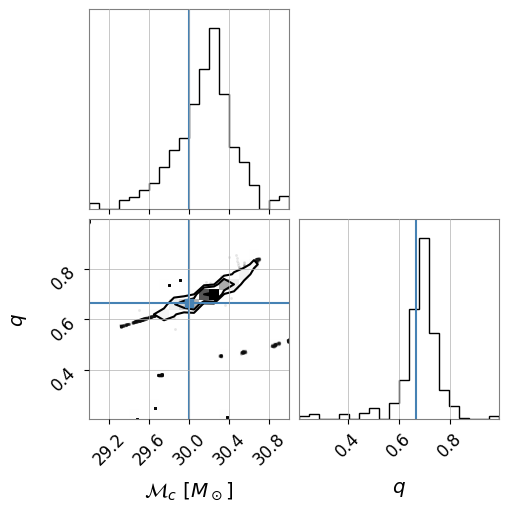

In [8]:
from corner import corner
import matplotlib.pyplot as plt
import numpy as np

samples = jim.get_samples()

fig = corner(
    np.column_stack([samples["M_c"], samples["q"]]),
    labels=[r"$\mathcal{M}_c\ [M_\odot]$", r"$q$"],
    truths=[
        injection_parameters["M_c"],
        MassRatioToSymmetricMassRatioTransform.inverse({"eta": injection_parameters["eta"]})[0]["q"],
    ],
)
plt.show()